## Deep Learning for prediction of the effective contact area

Install guide: https://heads0rtai1s.github.io/2021/02/25/gpu-setup-r-python-ubuntu/

### import libraries

In [17]:
# tensorflow libraries
import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import plot_model

# preprocessing libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import pandas as pd 
import matplotlib.pyplot as plt # page 305
from pydeep_sim.machine_learning.preprocessing.preprocessing import MachineLearningPreprocess

import seaborn as sns
import math

In [4]:
# check if GPU support available
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [35]:
#load the data and 
file = "/home/a11btasa/rough_surface_ML/simulation_results_210721/simulation_output_Rough_Surface_Contact_Automatized_Simulation_10000_21July2021.dat"
df = pd.read_csv(file, sep="\t")
df.head()

,total_force,total_cont_area,mean_z_peaks,rms_z_peaks,ks_z_peaks,sk_z_peaks,mean_curv_peaks,ks_curv_peaks,sk_curv_peaks,dn_peaks,...,nu1,E2,nu2,lato,g0,H,n,Delta,errf,tol
0,433.85671,0.21953,23.58209,7.31704,2.66551,0.27834,0.16809,0.43032,0.71642,0.26049,...,0.3,1.0,0.3,1000.0,50.0,0.51409,8,10.0,100000000.0,0.01
1,1062.33891,0.94946,28.15027,8.18726,2.56147,-0.06719,0.03642,1.03779,0.77652,0.22439,...,0.3,1.0,0.3,1000.0,50.0,0.80000,7,10.0,100000000.0,0.01
2,718.92006,0.41114,25.06586,8.68357,2.56022,0.29845,0.24066,0.57982,0.74744,0.25122,...,0.3,1.0,0.3,1000.0,50.0,0.59463,9,10.0,100000000.0,0.01
3,992.78460,0.84937,27.70384,9.19090,3.05473,-0.41380,0.07992,0.87660,0.79104,0.22710,...,0.3,1.0,0.3,1000.0,50.0,0.72550,8,10.0,100000000.0,0.01
4,765.30384,0.35339,26.80894,8.15616,2.51534,0.05612,0.31718,0.60220,0.74906,0.24513,...,0.3,1.0,0.3,1000.0,50.0,0.64698,9,10.0,100000000.0,0.01


In [36]:
preprocessing_block =   {
                                "targets" : ["total_cont_area"],
                                "dropper" : ["E1", "nu1", "E2", "nu2", "lato", "g0", "Delta", "errf", "tol", "total_force"],
                                "model_split":  {
                                                "train_size" : 0.8,
                                                "random_state" : 1
                                                },              
                                "scaler" : {
                                            "type":"normalizer",           
                                            "options" : {
                                                        "norm" : "l2"
                                                        }           
                                            },
                        }

In [37]:
N_train_full, N_test = train_test_split(df["n"], train_size = 0.8, random_state = 1)
N_train_full.reset_index(drop=True, inplace=True)
N_test.reset_index(drop=True, inplace=True)
N_train, N_valid = train_test_split(N_train_full, train_size = 0.8, random_state = 1)

H_train_full, H_test = train_test_split(df["H"], train_size = 0.8, random_state = 1)
H_train_full.reset_index(drop=True, inplace=True)
H_test.reset_index(drop=True, inplace=True)
H_train, H_valid = train_test_split(H_train_full, train_size = 0.8, random_state = 1)

In [38]:
preprocesser = MachineLearningPreprocess(data=df, preprocess_block=preprocessing_block)
X_train_full, X_test, y_train_full, y_test = preprocesser.generate_processed_data()
print(X_train_full.shape)
print(y_train_full.shape)
print(X_test.shape)
print(y_test.shape)

(7989, 23)
(7989, 1)
(1998, 23)
(1998, 1)


In [39]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, train_size=0.8, random_state=1)
print(X_train.shape)
print(y_train.shape)
print(X_valid.shape)
print(y_valid.shape)

(6391, 23)
(6391, 1)
(1598, 23)
(1598, 1)


# Model 1: narrow architecture
 ## - 3 dense layers with ReLu activation
 ## - output activation ReLu

In [40]:

model_1 = keras.Sequential([
    layers.Dense(units=10, activation=tf.nn.relu, input_shape=X_train.shape[1:], name="Hidden_layer_1"),
    layers.Dense(units=2, activation=tf.nn.relu, name="Hidden_layer_2"),
    layers.Dense(units=1, activation=tf.nn.relu, name="Output_layer")
], name="model_1")

model_1.compile(loss="mse",
            optimizer="sgd",
            metrics=[keras.metrics.mean_absolute_percentage_error, keras.metrics.mean_absolute_error])

model_1.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
Hidden_layer_1 (Dense)       (None, 10)                240       
_________________________________________________________________
Hidden_layer_2 (Dense)       (None, 2)                 22        
_________________________________________________________________
Output_layer (Dense)         (None, 1)                 3         
Total params: 265
Trainable params: 265
Non-trainable params: 0
_________________________________________________________________


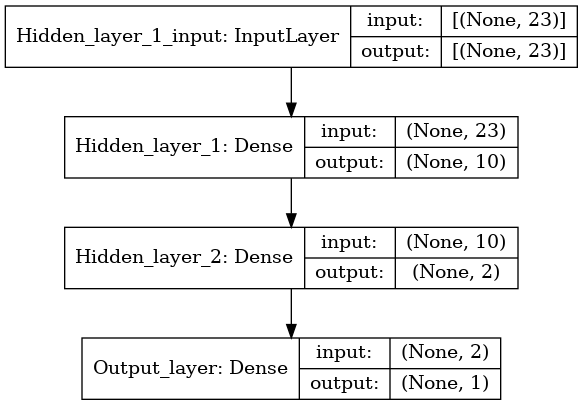

In [41]:
plot_model(model_1, to_file=model_1.name+".png", show_shapes=True, show_layer_names=True)

In [42]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(filepath=(model_1.name+".h5"))
early_stopping_cb = keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)

history_1 = model_1.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), batch_size=32, callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
200/200 [==============================] - 1s 2ms/step - loss: 0.2145 - mean_absolute_percentage_error: 87.4167 - mean_absolute_error: 0.3287 - val_loss: 0.2086 - val_mean_absolute_percentage_error: 83.6332 - val_mean_absolute_error: 0.3259
Epoch 2/100
200/200 [==============================] - 0s 2ms/step - loss: 0.1954 - mean_absolute_percentage_error: 87.4917 - mean_absolute_error: 0.3157 - val_loss: 0.2025 - val_mean_absolute_percentage_error: 79.1443 - val_mean_absolute_error: 0.3175
Epoch 3/100
200/200 [==============================] - 0s 2ms/step - loss: 0.1920 - mean_absolute_percentage_error: 85.8914 - mean_absolute_error: 0.3119 - val_loss: 0.1999 - val_mean_absolute_percentage_error: 82.8758 - val_mean_absolute_error: 0.3215
Epoch 4/100
200/200 [==============================] - 0s 2ms/step - loss: 0.1909 - mean_absolute_percentage_error: 85.7151 - mean_absolute_error: 0.3112 - val_loss: 0.1991 - val_mean_absolute_percentage_error: 81.0441 - val_mean_absolute_er

In [37]:
test_loss_1 = model_1.evaluate(X_train, y_train, batch_size=32)

200/200 [==============================] - 0s 1ms/step - loss: 0.0524 - mean_absolute_percentage_error: 30.2342 - mean_absolute_error: 0.1468


<function matplotlib.pyplot.show(close=None, block=None)>

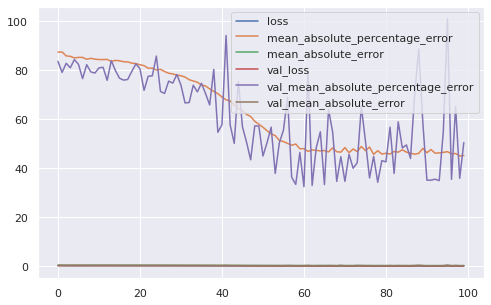

In [43]:
pd.DataFrame(history_1.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show

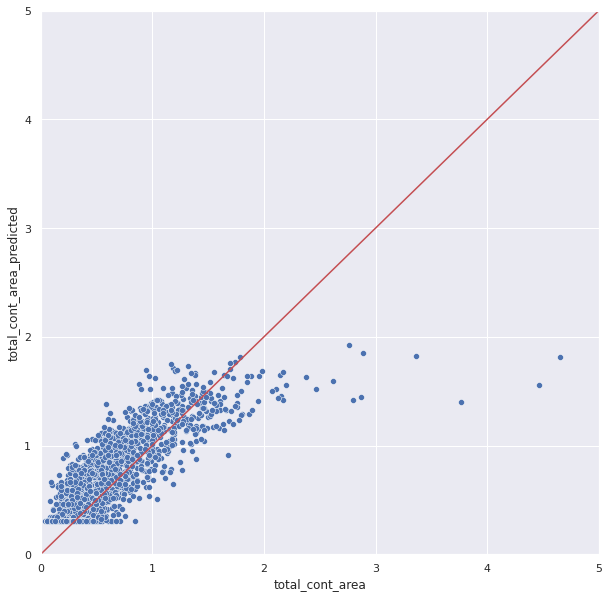

In [54]:
import seaborn as sns 
import matplotlib.pyplot as plt
import math
sns.set_theme()

y_pred = pd.DataFrame(model_1.predict(X_test), columns=["total_cont_area_predicted"])
combined = pd.concat([y_pred, y_test], axis=1)
lim = math.ceil(y_test.max())
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, data=combined, x = "total_cont_area", y = "total_cont_area_predicted")
plt.plot([0,lim],[0, lim], 'r')
plt.ylim(0, lim)
plt.xlim(0, lim)
plt.savefig("model_1_pred_vs_truth.png")

In [49]:
def build_deep_model(drop_out_rate, model_name):

    model = keras.Sequential([
                            layers.Dense(units=150, input_shape=X_train.shape[1:], activation=tf.nn.relu, name="dense_layer_1"),
                            layers.Dropout(rate=drop_out_rate, name="dropout_layer_1"),
                            layers.Dense(units=200, activation=tf.nn.relu, name="dense_layer_2"),
                            layers.Dropout(rate=drop_out_rate, name="dropout_layer_2"),
                            layers.Dense(units=250, activation=tf.nn.relu, name="denselayer_3"),
                            layers.Dropout(rate=drop_out_rate, name="dropout_layer_3"),
                            layers.Dense(units=200, activation=tf.nn.relu, name="dense_layer_4"),
                            layers.Dropout(rate=drop_out_rate, name="dropout_layer_4"),
                            layers.Dense(units=150, activation=tf.nn.relu, name="dense_layer_5"),
                            layers.Dropout(rate=drop_out_rate, name="dropout_layer_5"),
                            layers.Dense(units=1, activation=tf.math.softplus, name="Output_layer")
                            ], 
                            name=model_name)

    return model

# Model 2: Deep architecture
 ## - 5 dense layers with ReLu activation
 ## - 5 Dropout layers with 0.1 droput rate
 ## - output activation softplus

In [56]:
drop_out_rate = 0.1
model_2 = build_deep_model(drop_out_rate=drop_out_rate,model_name="model_2")

model_2.compile(loss="mse",
            optimizer=keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
            metrics=[keras.metrics.mean_absolute_percentage_error, keras.metrics.mean_absolute_error])


model_2.summary()


Model: "model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_layer_1 (Dense)        (None, 150)               3600      
_________________________________________________________________
dropout_layer_1 (Dropout)    (None, 150)               0         
_________________________________________________________________
dense_layer_2 (Dense)        (None, 200)               30200     
_________________________________________________________________
dropout_layer_2 (Dropout)    (None, 200)               0         
_________________________________________________________________
denselayer_3 (Dense)         (None, 250)               50250     
_________________________________________________________________
dropout_layer_3 (Dropout)    (None, 250)               0         
_________________________________________________________________
dense_layer_4 (Dense)        (None, 200)               5020

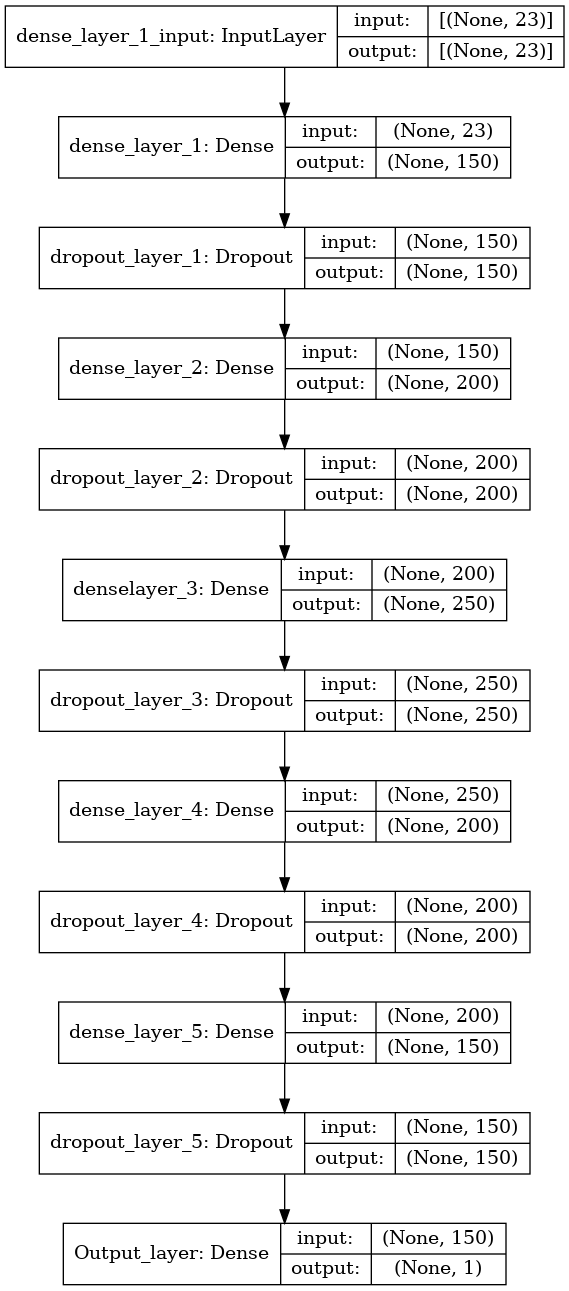

In [57]:
plot_model(model_2, to_file=model_2.name+".png", show_shapes=True, show_layer_names=True)

In [58]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(filepath=(model_2.name+".h5"))
early_stopping_cb = keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)

history_2 = model_2.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), batch_size=32, callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
200/200 [==============================] - 1s 3ms/step - loss: 0.1761 - mean_absolute_percentage_error: 78.7735 - mean_absolute_error: 0.2951 - val_loss: 0.1043 - val_mean_absolute_percentage_error: 53.7094 - val_mean_absolute_error: 0.2214
Epoch 2/100
200/200 [==============================] - 0s 2ms/step - loss: 0.1183 - mean_absolute_percentage_error: 56.7141 - mean_absolute_error: 0.2348 - val_loss: 0.0822 - val_mean_absolute_percentage_error: 39.8046 - val_mean_absolute_error: 0.1853
Epoch 3/100
200/200 [==============================] - 0s 2ms/step - loss: 0.0909 - mean_absolute_percentage_error: 49.2005 - mean_absolute_error: 0.2075 - val_loss: 0.0731 - val_mean_absolute_percentage_error: 37.4769 - val_mean_absolute_error: 0.1737
Epoch 4/100
200/200 [==============================] - 0s 2ms/step - loss: 0.0783 - mean_absolute_percentage_error: 44.1357 - mean_absolute_error: 0.1916 - val_loss: 0.0657 - val_mean_absolute_percentage_error: 30.4706 - val_mean_absolute_er

<function matplotlib.pyplot.show(close=None, block=None)>

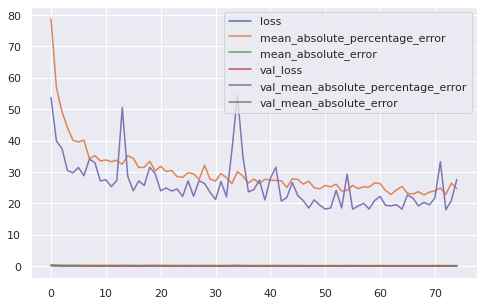

In [59]:
pd.DataFrame(history_2.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show

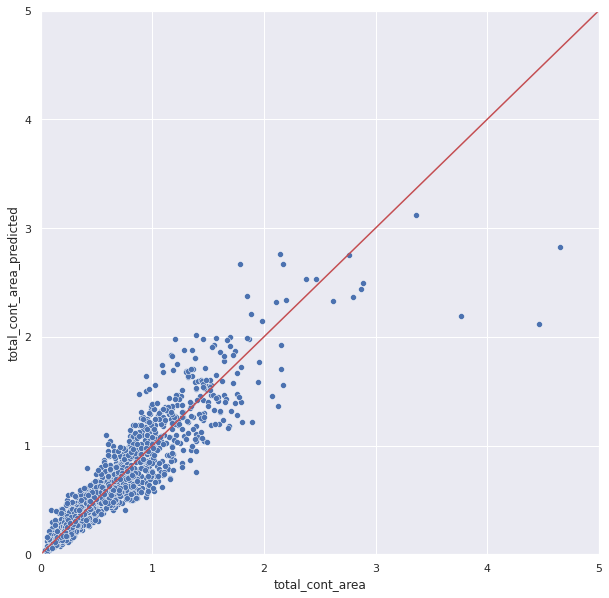

In [55]:
sns.set_theme()

y_pred = pd.DataFrame(model_2.predict(X_test), columns=["total_cont_area_predicted"])
combined = pd.concat([y_pred, y_test], axis=1)
lim = math.ceil(y_test.max())
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, data=combined, x = "total_cont_area", y = "total_cont_area_predicted")
plt.plot([0,lim],[0, lim], 'r')
plt.ylim(0, lim)
plt.xlim(0, lim)
plt.savefig("model_2_pred_vs_truth.png")

# Model 3: Deep architecture
 ## - 5 dense layers with ReLu activation
 ## - 5 Dropout layers with 0.05 droput rate
 ## - output activation softplus

In [67]:
drop_out_rate = 0.05
model_3 = build_deep_model(drop_out_rate=drop_out_rate,model_name="model_3")

model_3.compile(loss="mse",
            optimizer=keras.optimizers.Adam(learning_rate=0.0005),
            metrics=[keras.metrics.mean_absolute_percentage_error, keras.metrics.mean_absolute_error])

model_3.summary()

Model: "model_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_layer_1 (Dense)        (None, 150)               3600      
_________________________________________________________________
dropout_layer_1 (Dropout)    (None, 150)               0         
_________________________________________________________________
dense_layer_2 (Dense)        (None, 200)               30200     
_________________________________________________________________
dropout_layer_2 (Dropout)    (None, 200)               0         
_________________________________________________________________
denselayer_3 (Dense)         (None, 250)               50250     
_________________________________________________________________
dropout_layer_3 (Dropout)    (None, 250)               0         
_________________________________________________________________
dense_layer_4 (Dense)        (None, 200)               5020

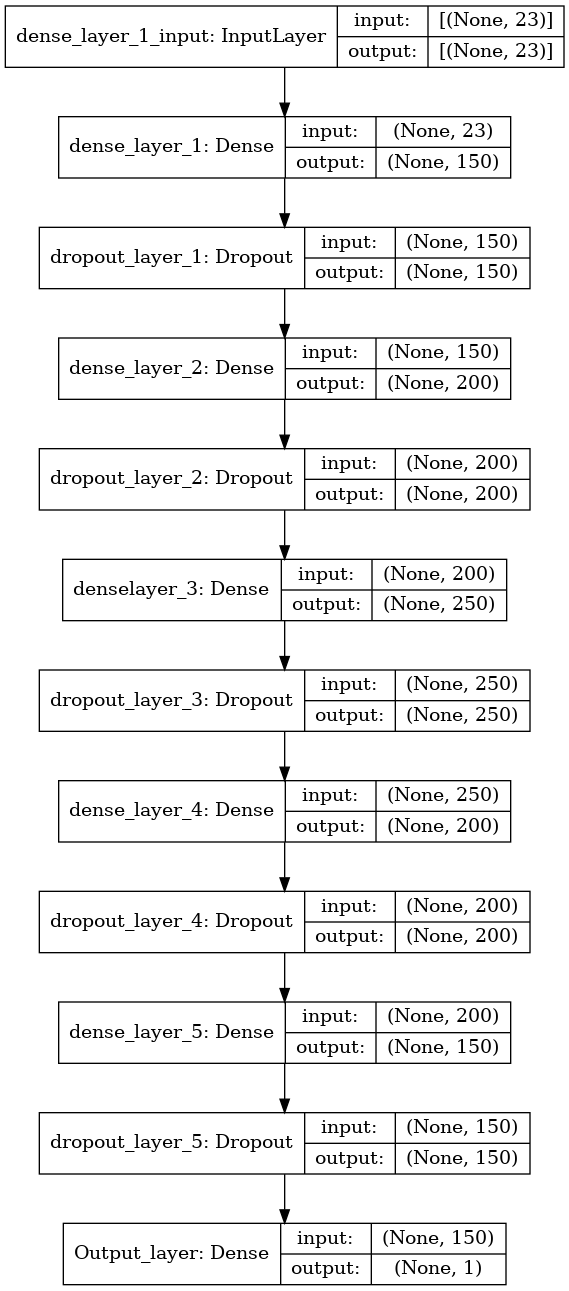

In [68]:
plot_model(model_3, to_file=model_3.name+".png", show_shapes=True, show_layer_names=True)

In [69]:

checkpoint_cb = keras.callbacks.ModelCheckpoint(model_3.name+".h5")
early_stopping_cb = keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)

history_3 = model_3.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), batch_size=32, callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
200/200 [==============================] - 1s 3ms/step - loss: 0.1788 - mean_absolute_percentage_error: 80.1388 - mean_absolute_error: 0.2974 - val_loss: 0.1135 - val_mean_absolute_percentage_error: 53.5968 - val_mean_absolute_error: 0.2269
Epoch 2/100
200/200 [==============================] - 0s 2ms/step - loss: 0.1130 - mean_absolute_percentage_error: 54.4197 - mean_absolute_error: 0.2302 - val_loss: 0.0755 - val_mean_absolute_percentage_error: 48.0495 - val_mean_absolute_error: 0.1923
Epoch 3/100
200/200 [==============================] - 0s 2ms/step - loss: 0.0882 - mean_absolute_percentage_error: 47.8732 - mean_absolute_error: 0.2028 - val_loss: 0.0654 - val_mean_absolute_percentage_error: 42.1352 - val_mean_absolute_error: 0.1771
Epoch 4/100
200/200 [==============================] - 0s 2ms/step - loss: 0.0785 - mean_absolute_percentage_error: 44.3736 - mean_absolute_error: 0.1911 - val_loss: 0.0554 - val_mean_absolute_percentage_error: 34.2849 - val_mean_absolute_er

<function matplotlib.pyplot.show(close=None, block=None)>

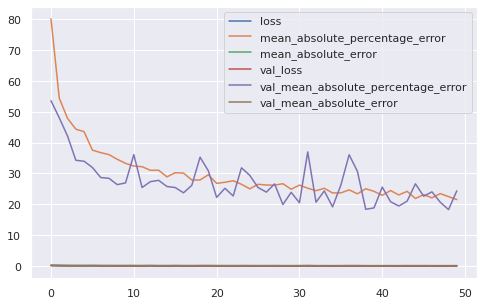

In [70]:
pd.DataFrame(history_3.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show

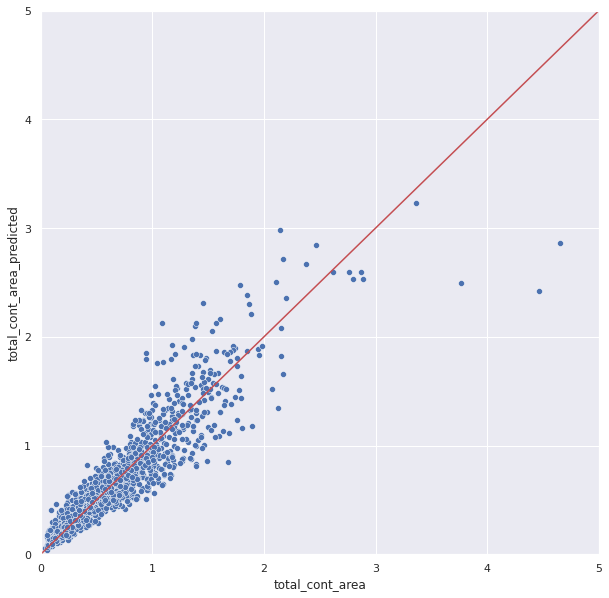

In [71]:
sns.set_theme()

y_pred = pd.DataFrame(model_3.predict(X_test), columns=["total_cont_area_predicted"])
combined = pd.concat([y_pred, y_test], axis=1)
lim = math.ceil(y_test.max())
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, data=combined, x = "total_cont_area", y = "total_cont_area_predicted")
plt.plot([0,lim],[0, lim], 'r')
plt.ylim(0, lim)
plt.xlim(0, lim)
plt.savefig(model_3.name+"_pred_vs_truth.png")

In [95]:
def build_deeper_model_bn(drop_out_rate):
    
    model = keras.Sequential([
                            layers.Dense(units=128, activation=tf.nn.relu, name="Hidden_layer_1", input_shape=X_train.shape[1:], kernel_initializer="he_normal",
kernel_regularizer=keras.regularizers.l2(0.01)),
                            layers.BatchNormalization(),
                            layers.Dense(units=256, activation=tf.nn.relu, name="Hidden_layer_2"),
                            layers.BatchNormalization(),

                            layers.Dense(units=256, activation=tf.nn.relu, name="Hidden_layer_3", kernel_initializer="he_normal",
                            kernel_regularizer=keras.regularizers.l2(0.01)),
                            layers.BatchNormalization(),

                            layers.Dense(units=256, activation=tf.nn.relu, name="Hidden_layer_4"),
                            layers.BatchNormalization(),
                            
                            #layers.Dropout(rate=drop_out_rate),

                            layers.Dense(units=384, activation=tf.nn.relu, name="Hidden_layer_5", kernel_initializer="he_normal",
                            kernel_regularizer=keras.regularizers.l2(0.01)),
                            layers.BatchNormalization(),

                            layers.Dense(units=512, activation=tf.nn.relu, name="Hidden_layer_6"),
                            layers.BatchNormalization(),
                            
                            #layers.Dropout(rate=drop_out_rate),

                            layers.Dense(units=512, activation=tf.nn.relu, name="Hidden_layer_7", kernel_initializer="he_normal",
                            kernel_regularizer=keras.regularizers.l2(0.01)),
                            layers.BatchNormalization(),

                            layers.Dense(units=384, activation=tf.nn.relu, name="Hidden_layer_8"),
                            layers.BatchNormalization(),

                            layers.Dense(units=256, activation=tf.nn.relu, name="Hidden_layer_9", kernel_initializer="he_normal",
                            kernel_regularizer=keras.regularizers.l2(0.01)),
                            layers.BatchNormalization(),

                            layers.Dense(units=256, activation=tf.nn.relu, name="Hidden_layer_10"),
                            layers.BatchNormalization(),

                            #layers.Dropout(rate=drop_out_rate),

                            layers.Dense(units=256, activation=tf.nn.relu, name="Hidden_layer_11",kernel_initializer="he_normal",
                            kernel_regularizer=keras.regularizers.l2(0.01)),
                            layers.BatchNormalization(),
     
                            layers.Dense(units=128, activation=tf.nn.relu, name="Hidden_layer_12"),
                            layers.BatchNormalization(),
       
                            layers.Dense(units=1, activation=tf.math.softplus, name="Output_layer")
                            ])

    return model

# Model 4: Deep architecture
 ## - 5 dense layers with ReLu activation + he_normal initialization + reqgularization 0.01
 ## - 5 batch normalization layers
 ## - output activation softplus

In [74]:
def build_deep_model_bn(model_name):
    
    model = keras.Sequential([
                            layers.Dense(units=150, input_shape=X_train.shape[1:], activation=tf.nn.relu, name="dense_layer_1", 
                            kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.01)),
                            layers.BatchNormalization(),
                            layers.Dense(units=200, activation=tf.nn.relu, name="dense_layer_2",
                            kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.01)),
                            layers.BatchNormalization(),
                            layers.Dense(units=250, activation=tf.nn.relu, name="denselayer_3",
                            kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.01)),
                            layers.BatchNormalization(),
                            layers.Dense(units=200, activation=tf.nn.relu, name="dense_layer_4",
                            kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.01)),
                            layers.BatchNormalization(),
                            layers.Dense(units=150, activation=tf.nn.relu, name="dense_layer_5",
                            kernel_initializer="he_normal", kernel_regularizer=keras.regularizers.l2(0.01)),
                            layers.BatchNormalization(),
                            layers.Dense(units=1, activation=tf.math.softplus, name="Output_layer")
                            ], 
                            name=model_name)

    return model

In [75]:
model_4 = build_deep_model_bn(model_name="model_4")

model_4.compile(loss="mse",
            optimizer=keras.optimizers.Nadam(learning_rate=0.0005),
            metrics=[keras.metrics.mean_absolute_percentage_error, keras.metrics.mean_absolute_error])

model_4.summary()

Model: "model_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_layer_1 (Dense)        (None, 150)               3600      
_________________________________________________________________
batch_normalization (BatchNo (None, 150)               600       
_________________________________________________________________
dense_layer_2 (Dense)        (None, 200)               30200     
_________________________________________________________________
batch_normalization_1 (Batch (None, 200)               800       
_________________________________________________________________
denselayer_3 (Dense)         (None, 250)               50250     
_________________________________________________________________
batch_normalization_2 (Batch (None, 250)               1000      
_________________________________________________________________
dense_layer_4 (Dense)        (None, 200)               5020

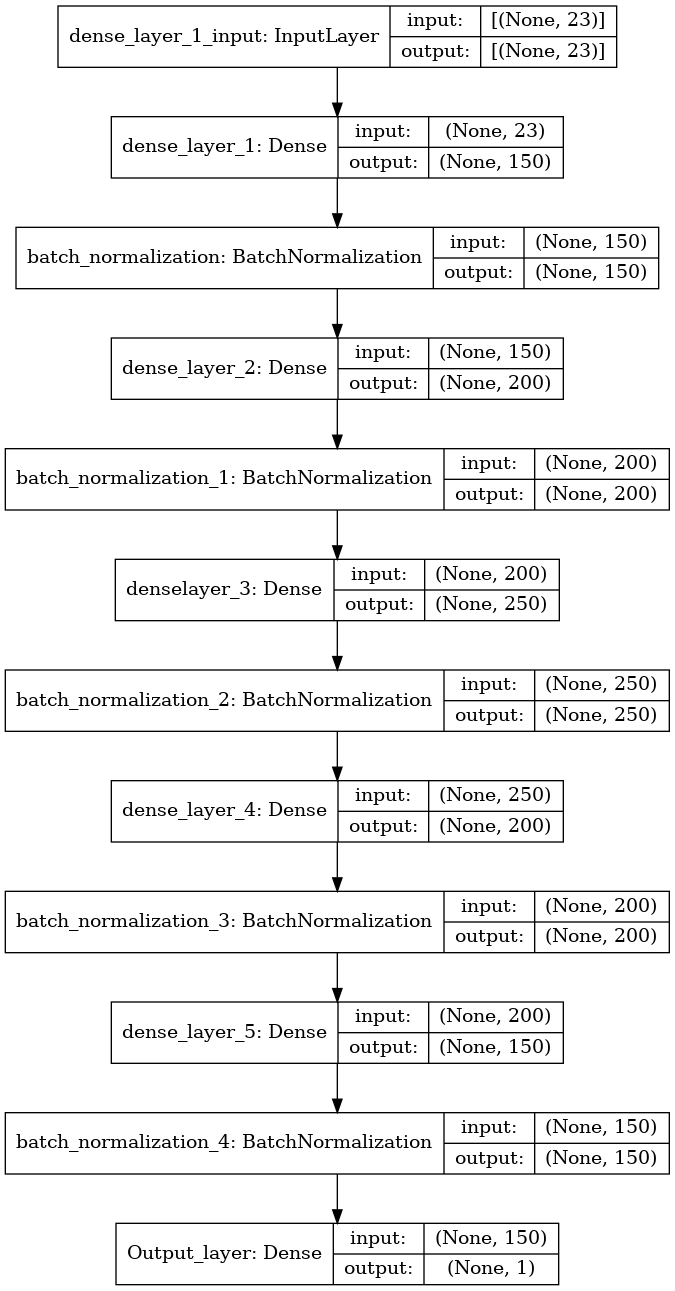

In [76]:
plot_model(model_4, to_file=model_4.name+".png", show_shapes=True, show_layer_names=True)

In [77]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(model_4.name+".h5")
early_stopping_cb = keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)

history_4 = model_4.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), batch_size=32, callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
200/200 [==============================] - 3s 6ms/step - loss: 15.9626 - mean_absolute_percentage_error: 61.5622 - mean_absolute_error: 0.2715 - val_loss: 12.8225 - val_mean_absolute_percentage_error: 78.2739 - val_mean_absolute_error: 0.3133
Epoch 2/100
200/200 [==============================] - 1s 6ms/step - loss: 10.2411 - mean_absolute_percentage_error: 37.9706 - mean_absolute_error: 0.1976 - val_loss: 8.1861 - val_mean_absolute_percentage_error: 73.5063 - val_mean_absolute_error: 0.3119
Epoch 3/100
200/200 [==============================] - 1s 6ms/step - loss: 6.4856 - mean_absolute_percentage_error: 36.9068 - mean_absolute_error: 0.1889 - val_loss: 5.1770 - val_mean_absolute_percentage_error: 73.5587 - val_mean_absolute_error: 0.2737
Epoch 4/100
200/200 [==============================] - 1s 6ms/step - loss: 4.1332 - mean_absolute_percentage_error: 34.5790 - mean_absolute_error: 0.1763 - val_loss: 3.3624 - val_mean_absolute_percentage_error: 73.9262 - val_mean_absolute

<function matplotlib.pyplot.show(close=None, block=None)>

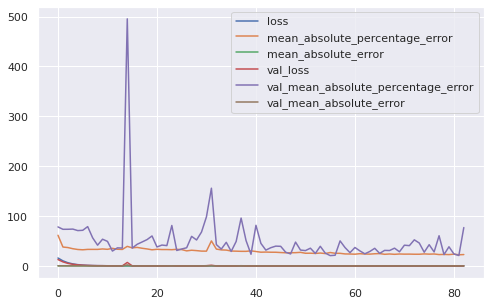

In [78]:
pd.DataFrame(history_4.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show

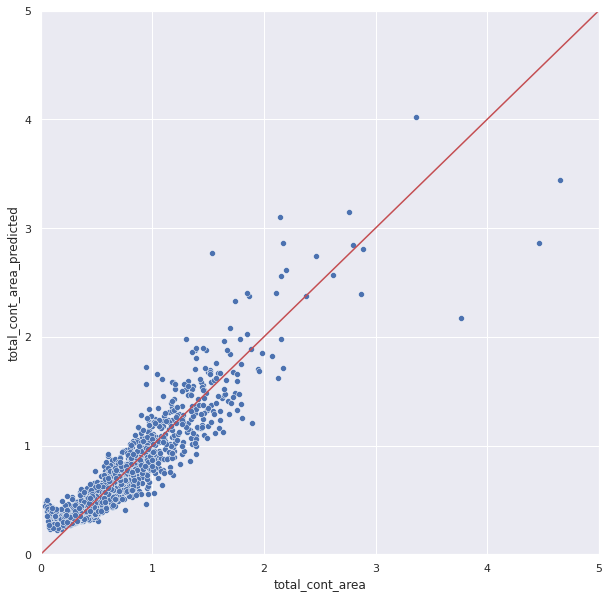

In [79]:
sns.set_theme()

y_pred = pd.DataFrame(model_4.predict(X_test), columns=["total_cont_area_predicted"])
combined = pd.concat([y_pred, y_test], axis=1)
lim = math.ceil(y_test.max())
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, data=combined, x = "total_cont_area", y = "total_cont_area_predicted")
plt.plot([0,lim],[0, lim], 'r')
plt.ylim(0, lim)
plt.xlim(0, lim)
plt.savefig(model_4.name+"_pred_vs_truth.png")

# Model 5: Mid-Deep architecture
 ## - 3 dense layers with ReLu activation
 ## - output activation ReLU

In [68]:
model_5 = keras.Sequential([
    layers.Dense(units=20, activation=tf.nn.relu, input_shape=X_train.shape[1:], name="Hidden_layer_1"),
    layers.Dense(units=40, activation=tf.nn.relu, name="Hidden_layer_2"),
    layers.Dense(units=40, activation=tf.nn.relu, name="Hidden_layer_3"),
    layers.Dense(units=1, activation=tf.nn.relu, name="Output_layer")
], name="model_5")

model_5.compile(loss="mse",
            optimizer=keras.optimizers.Nadam(learning_rate=0.0005),
            metrics=[keras.metrics.mean_absolute_percentage_error, keras.metrics.mean_absolute_error])

model_5.summary()

Model: "model_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
Hidden_layer_1 (Dense)       (None, 20)                480       
_________________________________________________________________
Hidden_layer_2 (Dense)       (None, 40)                840       
_________________________________________________________________
Hidden_layer_3 (Dense)       (None, 40)                1640      
_________________________________________________________________
Output_layer (Dense)         (None, 1)                 41        
Total params: 3,001
Trainable params: 3,001
Non-trainable params: 0
_________________________________________________________________


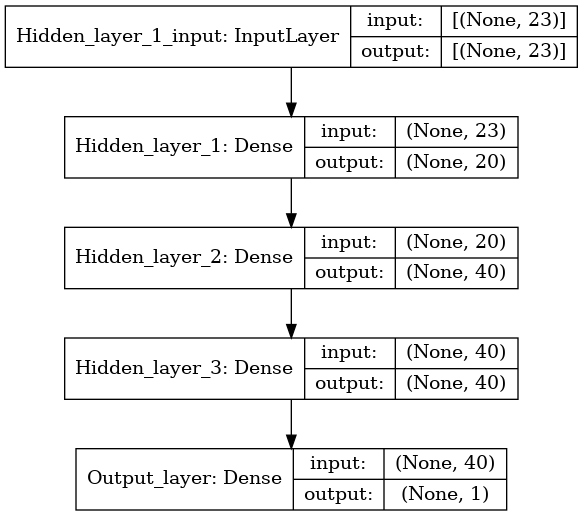

In [69]:
plot_model(model_5, to_file=model_5.name+".png", show_shapes=True, show_layer_names=True)

In [83]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(model_5.name+".h5")
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

history_5 = model_5.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), batch_size=32, callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
200/200 [==============================] - 1s 3ms/step - loss: 0.2209 - mean_absolute_percentage_error: 82.0305 - mean_absolute_error: 0.3302 - val_loss: 0.2016 - val_mean_absolute_percentage_error: 77.6604 - val_mean_absolute_error: 0.3152
Epoch 2/100
200/200 [==============================] - 1s 3ms/step - loss: 0.1881 - mean_absolute_percentage_error: 83.9267 - mean_absolute_error: 0.3076 - val_loss: 0.1914 - val_mean_absolute_percentage_error: 83.2259 - val_mean_absolute_error: 0.3177
Epoch 3/100
200/200 [==============================] - 1s 3ms/step - loss: 0.1781 - mean_absolute_percentage_error: 80.7363 - mean_absolute_error: 0.2980 - val_loss: 0.1772 - val_mean_absolute_percentage_error: 72.7092 - val_mean_absolute_error: 0.2946
Epoch 4/100
200/200 [==============================] - 1s 3ms/step - loss: 0.1600 - mean_absolute_percentage_error: 73.8247 - mean_absolute_error: 0.2784 - val_loss: 0.1532 - val_mean_absolute_percentage_error: 64.1595 - val_mean_absolute_er

<function matplotlib.pyplot.show(close=None, block=None)>

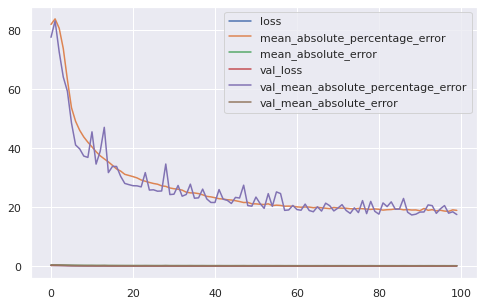

In [84]:
pd.DataFrame(history_5.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show

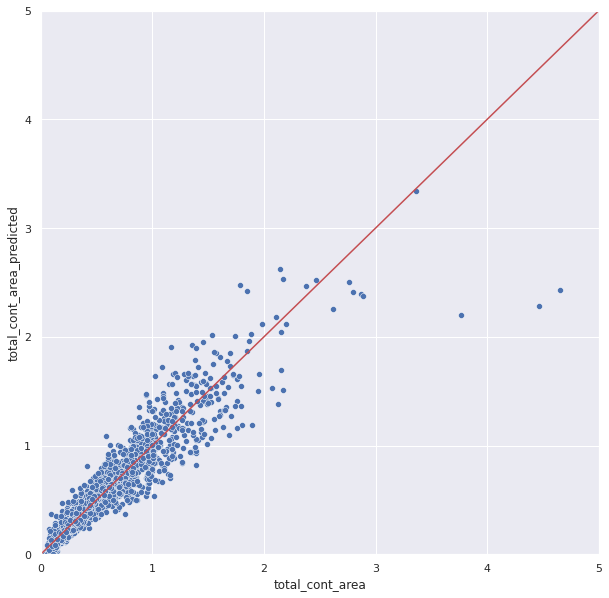

In [85]:
sns.set_theme()

y_pred = pd.DataFrame(model_5.predict(X_test), columns=["total_cont_area_predicted"])
combined = pd.concat([y_pred, y_test], axis=1)
lim = math.ceil(y_test.max())
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, data=combined, x = "total_cont_area", y = "total_cont_area_predicted")
plt.plot([0,lim],[0, lim], 'r')
plt.ylim(0, lim)
plt.xlim(0, lim)
plt.savefig(model_5.name+"_pred_vs_truth.png")

# Model 6: Mid-Deep architecture
 ## - 4 dense layers with ReLu activation with he_normal kernel initializer
 ## - output activation ReLU

In [86]:
model_6 = keras.Sequential([
    layers.Dense(units=20, activation=tf.nn.relu, input_shape=X_train.shape[1:], name="Hidden_layer_1", kernel_initializer="he_normal"),
    layers.Dense(units=40, activation=tf.nn.relu, name="Hidden_layer_2", kernel_initializer="he_normal"),
    layers.Dense(units=50, activation=tf.nn.relu, name="Hidden_layer_3", kernel_initializer="he_normal"),
    layers.Dense(units=40, activation=tf.nn.relu, name="Hidden_layer_4", kernel_initializer="he_normal"),
    layers.Dense(units=1, activation=tf.nn.relu, name="Output_layer")
], name="model_6")


model_6.compile(loss="mse",
            optimizer=keras.optimizers.Nadam(learning_rate=0.0005),
            metrics=[tf.metrics.mean_absolute_percentage_error, tf.metrics.mean_absolute_error])

model_6.summary()


Model: "model_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
Hidden_layer_1 (Dense)       (None, 20)                480       
_________________________________________________________________
Hidden_layer_2 (Dense)       (None, 40)                840       
_________________________________________________________________
Hidden_layer_3 (Dense)       (None, 50)                2050      
_________________________________________________________________
Hidden_layer_4 (Dense)       (None, 40)                2040      
_________________________________________________________________
Output_layer (Dense)         (None, 1)                 41        
Total params: 5,451
Trainable params: 5,451
Non-trainable params: 0
_________________________________________________________________


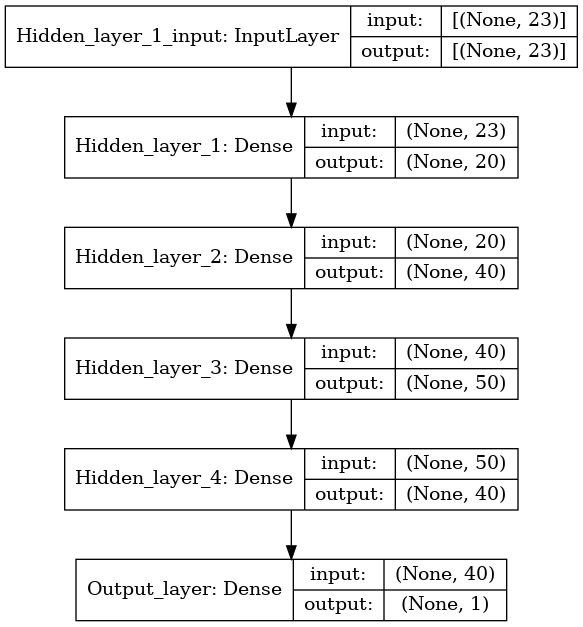

In [87]:
plot_model(model_6, to_file=model_6.name+".png", show_shapes=True, show_layer_names=True)

In [88]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(model_6.name+".h5")
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

history_6 = model_6.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), batch_size=32, callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
200/200 [==============================] - 1s 3ms/step - loss: 0.2054 - mean_absolute_percentage_error: 81.6720 - mean_absolute_error: 0.3193 - val_loss: 0.1953 - val_mean_absolute_percentage_error: 72.8204 - val_mean_absolute_error: 0.3055
Epoch 2/100
200/200 [==============================] - 1s 3ms/step - loss: 0.1767 - mean_absolute_percentage_error: 80.6030 - mean_absolute_error: 0.2968 - val_loss: 0.1730 - val_mean_absolute_percentage_error: 61.1666 - val_mean_absolute_error: 0.2776
Epoch 3/100
200/200 [==============================] - 1s 3ms/step - loss: 0.1435 - mean_absolute_percentage_error: 67.3786 - mean_absolute_error: 0.2610 - val_loss: 0.1297 - val_mean_absolute_percentage_error: 50.9214 - val_mean_absolute_error: 0.2343
Epoch 4/100
200/200 [==============================] - 1s 3ms/step - loss: 0.1149 - mean_absolute_percentage_error: 54.1885 - mean_absolute_error: 0.2267 - val_loss: 0.1325 - val_mean_absolute_percentage_error: 75.8575 - val_mean_absolute_er

<function matplotlib.pyplot.show(close=None, block=None)>

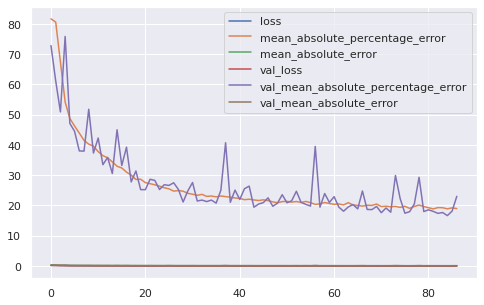

In [89]:
pd.DataFrame(history_6.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show

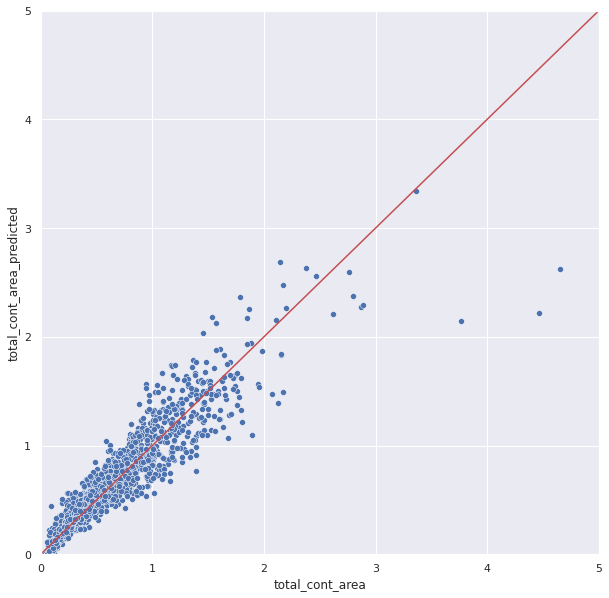

In [90]:
sns.set_theme()

y_pred = pd.DataFrame(model_6.predict(X_test), columns=["total_cont_area_predicted"])
combined = pd.concat([y_pred, y_test], axis=1)
lim = math.ceil(y_test.max())
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, data=combined, x = "total_cont_area", y = "total_cont_area_predicted")
plt.plot([0,lim],[0, lim], 'r')
plt.ylim(0, lim)
plt.xlim(0, lim)
plt.savefig(model_6.name+"_pred_vs_truth.png")

# Model 7: Mid-Deep architecture
 ## - 4 dense layers with ReLu activation with he_normal kernel initializer
 ## - 1 dropout layer
 ## - output activation ReLU

In [92]:
model_7 = keras.Sequential([
    layers.Dense(units=20, activation=tf.nn.relu, input_shape=X_train.shape[1:], name="Hidden_layer_1", kernel_initializer="he_normal"),
    layers.Dense(units=40, activation=tf.nn.relu, name="Hidden_layer_2", kernel_initializer="he_normal"),
    layers.Dense(units=50, activation=tf.nn.relu, name="Hidden_layer_3", kernel_initializer="he_normal"),
    layers.Dropout(rate=0.1),
    layers.Dense(units=40, activation=tf.nn.relu, name="Hidden_layer_4", kernel_initializer="he_normal"),
    layers.Dense(units=1, activation=tf.nn.relu, name="Output_layer")
], name="model_7")


model_7.compile(loss="mse",
            optimizer=keras.optimizers.Nadam(learning_rate=0.0005),
            metrics=[keras.metrics.mean_absolute_percentage_error, keras.metrics.mean_absolute_error])

model_7.summary()

Model: "model_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
Hidden_layer_1 (Dense)       (None, 20)                480       
_________________________________________________________________
Hidden_layer_2 (Dense)       (None, 40)                840       
_________________________________________________________________
Hidden_layer_3 (Dense)       (None, 50)                2050      
_________________________________________________________________
dropout_15 (Dropout)         (None, 50)                0         
_________________________________________________________________
Hidden_layer_4 (Dense)       (None, 40)                2040      
_________________________________________________________________
Output_layer (Dense)         (None, 1)                 41        
Total params: 5,451
Trainable params: 5,451
Non-trainable params: 0
_________________________________________________________

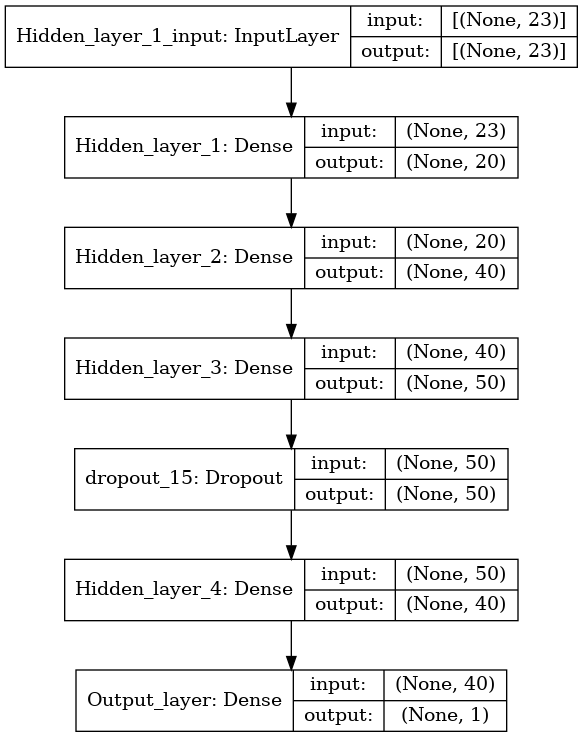

In [93]:
plot_model(model_7, to_file=model_7.name+".png", show_shapes=True, show_layer_names=True)

In [94]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(model_7.name+".h5")
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

history_7 = model_7.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), batch_size=32, callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
200/200 [==============================] - 1s 3ms/step - loss: 0.2077 - mean_absolute_percentage_error: 82.3568 - mean_absolute_error: 0.3220 - val_loss: 0.1853 - val_mean_absolute_percentage_error: 73.0235 - val_mean_absolute_error: 0.2992
Epoch 2/100
200/200 [==============================] - 1s 3ms/step - loss: 0.1630 - mean_absolute_percentage_error: 73.0101 - mean_absolute_error: 0.2809 - val_loss: 0.1480 - val_mean_absolute_percentage_error: 43.7650 - val_mean_absolute_error: 0.2384
Epoch 3/100
200/200 [==============================] - 1s 3ms/step - loss: 0.1216 - mean_absolute_percentage_error: 55.9471 - mean_absolute_error: 0.2349 - val_loss: 0.1103 - val_mean_absolute_percentage_error: 41.1345 - val_mean_absolute_error: 0.2061
Epoch 4/100
200/200 [==============================] - 1s 3ms/step - loss: 0.1003 - mean_absolute_percentage_error: 50.2603 - mean_absolute_error: 0.2149 - val_loss: 0.0868 - val_mean_absolute_percentage_error: 40.6216 - val_mean_absolute_er

<function matplotlib.pyplot.show(close=None, block=None)>

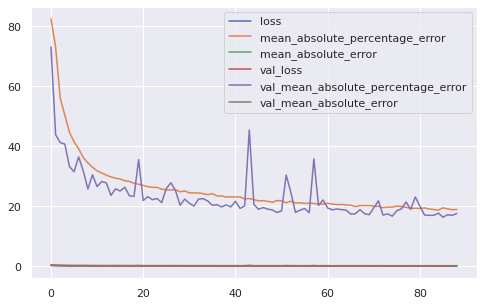

In [95]:
pd.DataFrame(history_7.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show

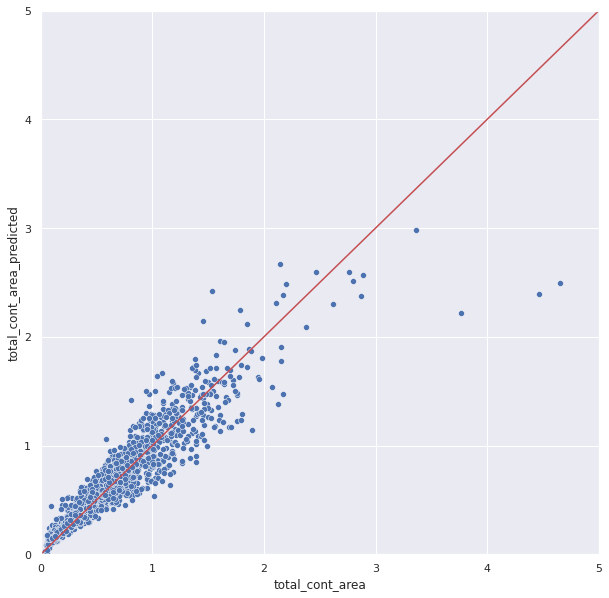

In [96]:
sns.set_theme()

y_pred = pd.DataFrame(model_7.predict(X_test), columns=["total_cont_area_predicted"])
combined = pd.concat([y_pred, y_test], axis=1)
lim = math.ceil(y_test.max())
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, data=combined, x = "total_cont_area", y = "total_cont_area_predicted")
plt.plot([0,lim],[0, lim], 'r')
plt.ylim(0, lim)
plt.xlim(0, lim)
plt.savefig(model_7.name+"_pred_vs_truth.png")

# Model 8: Mid-Deep architecture
 ## - 4 dense layers with eLu activation with he_normal kernel initializer
 ## - 1 dropout layer
 ## - output activation ReLU

In [122]:
model_8 = keras.Sequential([
    layers.Dense(units=30, activation=tf.nn.elu, input_shape=X_train.shape[1:], name="Hidden_layer_1", kernel_initializer="he_normal"),
    layers.Dense(units=80, activation=tf.nn.elu, name="Hidden_layer_2", kernel_initializer="he_normal"),
    layers.Dense(units=120, activation=tf.nn.elu, name="Hidden_layer_3", kernel_initializer="he_normal"),
    layers.Dropout(rate=0.1),
    layers.Dense(units=80, activation=tf.nn.elu, name="Hidden_layer_4", kernel_initializer="he_normal"),
    layers.Dense(units=1, activation=tf.nn.relu, name="Output_layer")
], name="model_8")


model_8.compile(loss="mse",
            optimizer=keras.optimizers.Nadam(learning_rate=0.0005),
            metrics=[keras.metrics.mean_absolute_percentage_error, keras.metrics.mean_absolute_error])

model_8.summary()

Model: "model_8"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
Hidden_layer_1 (Dense)       (None, 30)                720       
_________________________________________________________________
Hidden_layer_2 (Dense)       (None, 80)                2480      
_________________________________________________________________
Hidden_layer_3 (Dense)       (None, 120)               9720      
_________________________________________________________________
dropout_3 (Dropout)          (None, 120)               0         
_________________________________________________________________
Hidden_layer_4 (Dense)       (None, 80)                9680      
_________________________________________________________________
Output_layer (Dense)         (None, 1)                 81        
Total params: 22,681
Trainable params: 22,681
Non-trainable params: 0
_______________________________________________________

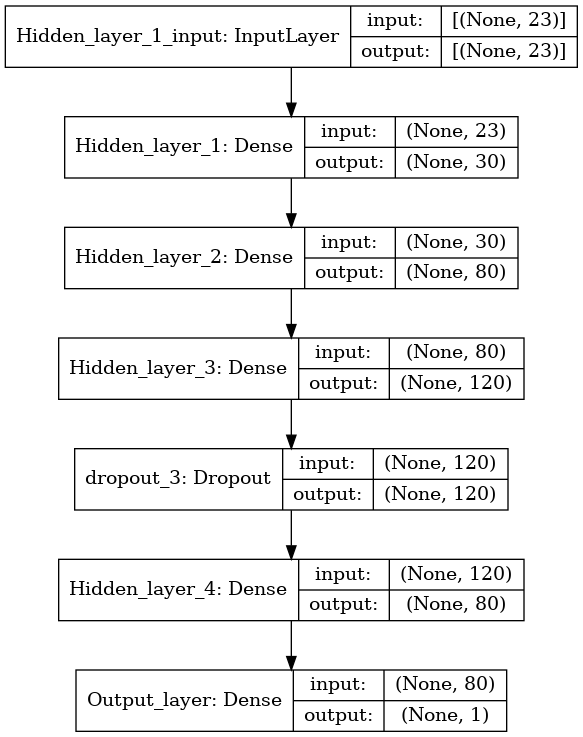

In [123]:
plot_model(model_8, to_file=model_8.name+".png", show_shapes=True, show_layer_names=True)

In [125]:
import time

checkpoint_cb = keras.callbacks.ModelCheckpoint(model_8.name+".h5")
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
start_time = time.time()
history_8 = model_8.fit(X_train, y_train, epochs=200, validation_data=(X_valid, y_valid), batch_size=32, callbacks=[checkpoint_cb, early_stopping_cb], shuffle=False)
end_time = time.time()
fit_time = end_time - start_time
print(fit_time)

Epoch 1/200
200/200 [==============================] - 1s 3ms/step - loss: 0.0300 - mean_absolute_percentage_error: 22.8660 - mean_absolute_error: 0.1132 - val_loss: 0.0233 - val_mean_absolute_percentage_error: 17.7212 - val_mean_absolute_error: 0.0967
Epoch 2/200
200/200 [==============================] - 1s 3ms/step - loss: 0.0298 - mean_absolute_percentage_error: 22.5208 - mean_absolute_error: 0.1124 - val_loss: 0.0231 - val_mean_absolute_percentage_error: 17.8637 - val_mean_absolute_error: 0.0964
Epoch 3/200
200/200 [==============================] - 1s 3ms/step - loss: 0.0290 - mean_absolute_percentage_error: 22.4092 - mean_absolute_error: 0.1119 - val_loss: 0.0236 - val_mean_absolute_percentage_error: 18.4491 - val_mean_absolute_error: 0.0990
Epoch 4/200
200/200 [==============================] - 1s 3ms/step - loss: 0.0297 - mean_absolute_percentage_error: 22.6558 - mean_absolute_error: 0.1124 - val_loss: 0.0232 - val_mean_absolute_percentage_error: 18.2487 - val_mean_absolute_er

<function matplotlib.pyplot.show(close=None, block=None)>

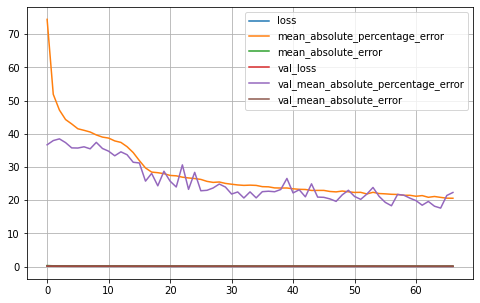

In [14]:
pd.DataFrame(history_8.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show

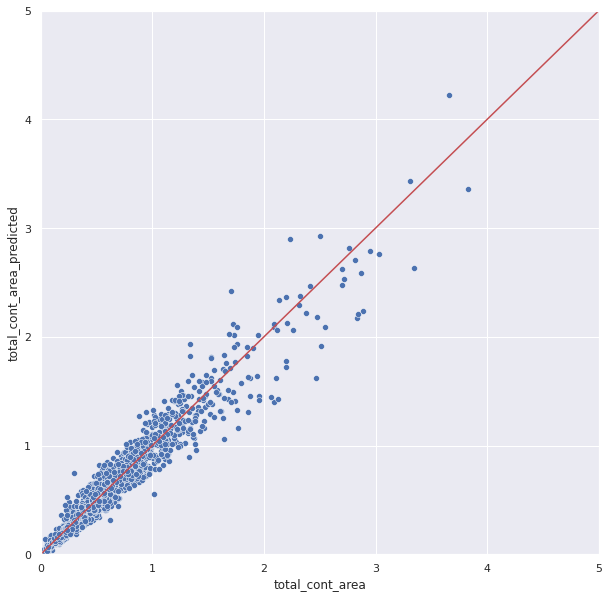

In [126]:
sns.set_theme()

y_pred = pd.DataFrame(model_8.predict(X_test), columns=["total_cont_area_predicted"])
combined = pd.concat([y_pred, y_test], axis=1)
lim = math.ceil(y_test.max())
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, data=combined, x = "total_cont_area", y = "total_cont_area_predicted")
plt.plot([0,lim+1],[0, lim+1], 'r')
plt.ylim(0, lim+1)
plt.xlim(0, lim+1)
plt.savefig(model_8.name+"_pred_vs_truth.png")

In [138]:
model_8.evaluate(X_train,y_train)

200/200 [==============================] - 0s 1ms/step - loss: 0.0149 - mean_absolute_percentage_error: 13.2502 - mean_absolute_error: 0.0730


[0.01488245464861393, 13.25015640258789, 0.07300473749637604]

In [144]:
model_8.evaluate(X_test,y_test)

63/63 [==============================] - 0s 1ms/step - loss: 0.0135 - mean_absolute_percentage_error: 13.2591 - mean_absolute_error: 0.0743


[0.01353309117257595, 13.259086608886719, 0.07428891211748123]

In [136]:
y_pred= model_8.predict(X_train)
keras.metrics.mean_squared_error(y_pred.reshape(-1), y_train.to_numpy().reshape(-1))

<tf.Tensor: shape=(), dtype=float64, numpy=0.014882461115528907>

In [119]:
import sklearn as sk
y_pred= model_8.predict(X_train)
max_train = sk.metrics.max_error(y_pred.reshape(-1), y_train.to_numpy().reshape(-1))
max_train

1.4465244316101074

In [120]:
y_pred= model_8.predict(X_test)
max_test = sk.metrics.max_error(y_pred.reshape(-1), y_test.to_numpy().reshape(-1))
max_test

1.9214795209503173

In [122]:
max_train_perc = max_train/y_train.max()*100
max_test_perc = max_test/y_test.max()*100

## R2 score

In [142]:
import tensorflow_addons as tfa

y_pred= model_8.predict(X_train)
metric = tfa.metrics.r_square.RSquare()
metric.update_state(y_pred.reshape(-1), y_train.to_numpy().reshape(-1))
r = metric.result()
r

<tf.Tensor: shape=(), dtype=float32, numpy=0.9185698>

In [143]:
y_pred= model_8.predict(X_test)
metric = tfa.metrics.r_square.RSquare()
metric.update_state(y_pred.reshape(-1), y_test.to_numpy().reshape(-1))
r = metric.result()
r

<tf.Tensor: shape=(), dtype=float32, numpy=0.931268>

## Percentage meansquared 

In [93]:
mse = history_8.history["loss"][-1]
mse_norm = mse/y_test["total_cont_area"].mean()*100
print(mse_norm)

3.709392975367736


In [96]:
history_8.history.keys()

dict_keys(['loss', 'mean_absolute_percentage_error', 'mean_absolute_error', 'val_loss', 'val_mean_absolute_percentage_error', 'val_mean_absolute_error'])

In [107]:
mae = history_8.history["mean_absolute_error"][-1]
mae_norm = mae/y_test["total_cont_area"].mean()*100
print(mae_norm)

14.011937124643847


(0.0, 5.0)

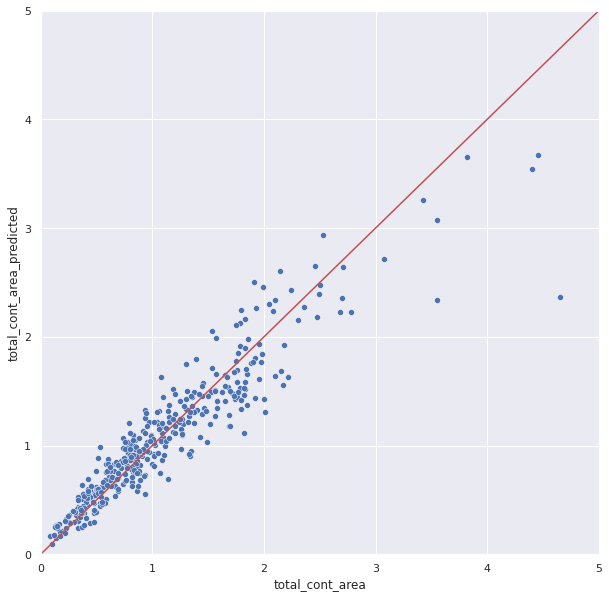

In [102]:
sns.set_theme()

h_level = pd.cut(H_train,4,labels=["1","2","3","4"])

y_train.reset_index(drop=True, inplace=True)
N_train.reset_index(drop=True, inplace=True)
h_level.reset_index(drop=True, inplace=True)
y_pred = pd.DataFrame(model_8.predict(X_train), columns=["total_cont_area_predicted"])
combined = pd.concat([y_pred, y_train, N_train, h_level], axis=1)
lim = math.ceil(y_train.max())
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, data=combined[(combined["n"]==7) & (combined["H"]=="1")], x = "total_cont_area", y = "total_cont_area_predicted")
plt.plot([0,lim],[0, lim], 'r')
plt.ylim(0, lim)
plt.xlim(0, lim)

(0.0, 5.0)

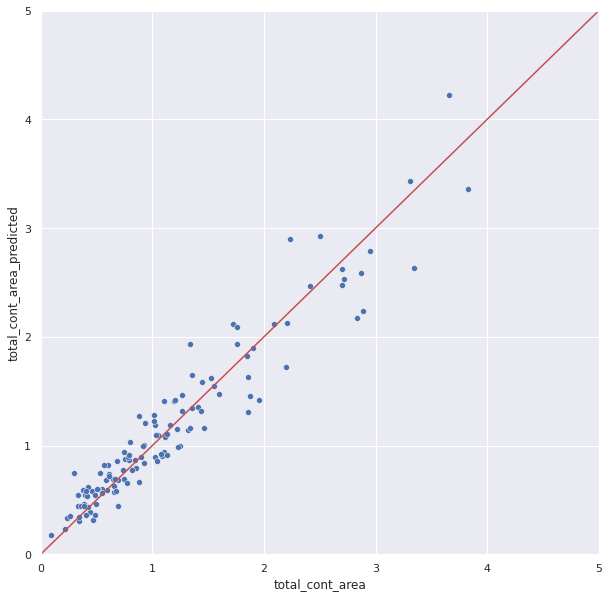

In [135]:
sns.set_theme()

h_level = pd.cut(H_test,4,labels=["1","2","3","4"])

y_train.reset_index(drop=True, inplace=True)
N_test.reset_index(drop=True, inplace=True)
h_level.reset_index(drop=True, inplace=True)
y_pred = pd.DataFrame(model_8.predict(X_test), columns=["total_cont_area_predicted"])
combined = pd.concat([y_pred, y_test, N_test, h_level], axis=1)
lim = math.ceil(y_test.max())
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, data=combined[(combined["n"]==7) & (combined["H"]=="4")], x = "total_cont_area", y = "total_cont_area_predicted")
plt.plot([0,lim+1],[0, lim+1], 'r')
plt.ylim(0, lim+1)
plt.xlim(0, lim+1)

In [30]:
data = combined[combined["n"]==7]
y_pred = data["total_cont_area_predicted"]
y_truth = data["total_cont_area"]
mse = keras.metrics.mean_squared_error(y_pred,y_truth)
mse_norm = mse/y_truth.mean()*100
print(mse_norm)

tf.Tensor(2.8678357812243216, shape=(), dtype=float64)


In [148]:
model_9 = keras.Sequential([
    layers.Dense(units=10, activation=tf.nn.relu, input_shape=X_train.shape[1:], name="Hidden_layer_1"),
    layers.Dense(units=4, activation=tf.nn.relu, name="Hidden_layer_2"),
    layers.Dense(units=1, activation=tf.nn.relu, name="Output_layer")
], name="model_9")

model_9.compile(loss="mse",
            optimizer=keras.optimizers.Nadam(learning_rate=0.0005),
            metrics=[keras.metrics.mean_absolute_percentage_error, keras.metrics.mean_absolute_error])

model_9.summary()

Model: "model_9"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
Hidden_layer_1 (Dense)       (None, 10)                240       
_________________________________________________________________
Hidden_layer_2 (Dense)       (None, 4)                 44        
_________________________________________________________________
Output_layer (Dense)         (None, 1)                 5         
Total params: 289
Trainable params: 289
Non-trainable params: 0
_________________________________________________________________


In [149]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(model_9.name+".h5")
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

history_9 = model_9.fit(X_train, y_train, epochs=200, validation_data=(X_valid, y_valid), batch_size=32, callbacks=[checkpoint_cb, early_stopping_cb], shuffle=False)

Epoch 1/200
200/200 [==============================] - 1s 3ms/step - loss: 0.1927 - mean_absolute_percentage_error: 81.7366 - mean_absolute_error: 0.3091 - val_loss: 0.1678 - val_mean_absolute_percentage_error: 82.5760 - val_mean_absolute_error: 0.3054
Epoch 2/200
200/200 [==============================] - 0s 2ms/step - loss: 0.1883 - mean_absolute_percentage_error: 83.2273 - mean_absolute_error: 0.3067 - val_loss: 0.1650 - val_mean_absolute_percentage_error: 81.8993 - val_mean_absolute_error: 0.3022
Epoch 3/200
200/200 [==============================] - 0s 2ms/step - loss: 0.1852 - mean_absolute_percentage_error: 82.5197 - mean_absolute_error: 0.3038 - val_loss: 0.1620 - val_mean_absolute_percentage_error: 81.0998 - val_mean_absolute_error: 0.2991
Epoch 4/200
200/200 [==============================] - 0s 2ms/step - loss: 0.1821 - mean_absolute_percentage_error: 81.6306 - mean_absolute_error: 0.3007 - val_loss: 0.1589 - val_mean_absolute_percentage_error: 80.1890 - val_mean_absolute_er

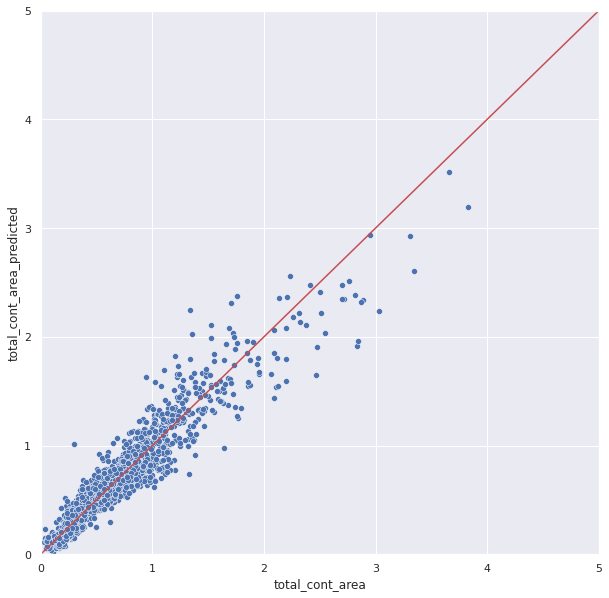

In [150]:
sns.set_theme()

y_pred = pd.DataFrame(model_9.predict(X_test), columns=["total_cont_area_predicted"])
combined = pd.concat([y_pred, y_test], axis=1)
lim = math.ceil(y_test.max())
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, data=combined, x = "total_cont_area", y = "total_cont_area_predicted")
plt.plot([0,lim+1],[0, lim+1], 'r')
plt.ylim(0, lim+1)
plt.xlim(0, lim+1)
plt.savefig(model_8.name+"_pred_vs_truth.png")